# 00. Observation and SBI Reader Guide

这是 notebooks 02-09 的阅读导航，不是新的scientific experiment。
它不复制大型输出、不重新运行simulation，也不产生posterior。

当前主线是：

`Observation schema -> schema freeze -> extractor parity -> training gate
-> diagnostic availability -> engineering adapter -> mapping audit ->
forward feasibility / Route decision`

必须先记住三条边界：

- 05和06没有实际posterior、coverage、recovery或PPC结果；
- 07证明adapter工程路径可运行，但semantic parity失败；
- 08只进行跨modality的shape-level screening，没有验证EEG measurement model。


## 1. Runtime and linked evidence

此block只核对notebook和HTML是否存在、记录当前kernel，并加载09生成的
registry。相对路径用于保证repo可迁移性。


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path
import platform
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from jupyter_client.kernelspec import KernelSpecManager

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / ".git").exists() and (PROJECT_ROOT / "S4_sbi").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate sleep_loop repository root")
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from sleep_sbi.forward_model_feasibility import (
    reader_guide_registry,
    route_decision_matrix,
)

OUTPUT_DIR = PROJECT_ROOT / "S4_sbi" / "results" / "observation_sbi_reader_guide"
FIGURE_DIR = OUTPUT_DIR / "figures"
HTML_DIR = PROJECT_ROOT / "S4_sbi" / "results" / "overnight_observation_ablation" / "html"
NOTEBOOK_PATH = PROJECT_ROOT / "S4_sbi" / "notebooks" / "00_Observation_SBI_Reader_Guide.ipynb"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

environment = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys_executable": sys.executable,
    "sys_prefix": sys.prefix,
    "python_version": platform.python_version(),
    "kernel_id": "python3",
    "kernel_display_name": KernelSpecManager().get_kernel_spec("python3").display_name,
}
assert environment["conda_environment"] == "neurolib"
assert "neurolib" in environment["sys_executable"].lower()
display(pd.DataFrame([environment]))


,created_utc,conda_environment,sys_executable,sys_prefix,python_version,kernel_id,kernel_display_name
0,2026-07-27T14:49:07.229343+00:00,neurolib,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,3.10.20,python3,Python 3 (ipykernel)


## 2. Notebook 02-09 workflow

图中的箭头表示证据依赖，不表示每一步都成功。红色节点是hard
blocker或NO-GO；蓝色节点是已完成的审计/工程工作；绿色仅表示阅读入口，
不代表SNPE已获批准。


,notebook,title,scientific_question,inputs,current_conclusion,priority_sections_or_figures,cannot_claim,notebook_path,html_path,notebook_exists,html_exists
0,02,Observation schema comparison,What are the executable Baseline and candidate...,01 observation artifacts,"Actual Baseline-14D, Augmented-23D, constructi...","Sections 3, 6, 11",Schema names are not evidence of simulator parity,S4_sbi/notebooks/02_Observation_Schema_Compari...,S4_sbi/results/observation_schema_comparison/0...,True,True
1,03,Observation schema freeze,Which real-EEG candidate schemas are finite an...,02 artifacts,No schema approved because simulation extracti...,Freeze decision; Go/No-Go; role figure,A frozen real vector alone is insufficient,S4_sbi/notebooks/03_Observation_Schema_Freeze....,S4_sbi/results/overnight_observation_ablation/...,True,True
2,04,Real-simulation extractor parity,Can existing simulation assets produce same-se...,03 schemas and legacy banks,NO-GO: legacy banks are 5D/7D rate summaries,Asset audit; feature failures; hard gate,Code-level availability is not semantic parity,S4_sbi/notebooks/04_Real_Simulation_Extractor_...,S4_sbi/results/overnight_observation_ablation/...,True,True
3,05,Pilot SNPE ablation,Did any schema pass the training gate?,04 gate,Training not started; zero simulations and zer...,Gate before training; manifest; blocker table,Contains no posterior,S4_sbi/notebooks/05_Pilot_SNPE_Ablation.ipynb,S4_sbi/results/overnight_observation_ablation/...,True,True
4,06,Ablation diagnostics,"Which recovery, coverage or PPC results exist?",05 artifacts,All diagnostic entries are insufficient evidence,Ablation summary; availability figure; conclusion,Contains no recovery/coverage/PPC result,S4_sbi/notebooks/06_Ablation_Diagnostics.ipynb,S4_sbi/results/overnight_observation_ablation/...,True,True
5,07,Simulator observable adapter,Can existing V7/V8/V8a rate signals enter shar...,Model parameter sets and EEG functions,Engineering adapter works; semantic parity fails,Adapter contract; blocker matrix; NO-GO gate,Cortical firing rate is not simulated EEG,S4_sbi/notebooks/07_Simulator_Observable_Adapt...,S4_sbi/results/simulator_observable_adapter_va...,True,True
6,08,EEG observation mapping audit,Do any recorded model states already constitut...,"07 artifacts, ALN/thalamic states, real EEG",Only standardized shape screening; no measurem...,State catalog; PSD/ACF screening; Route decision,High shape correlation is not EEG validation,S4_sbi/notebooks/08_EEG_Observation_Mapping_Au...,S4_sbi/results/overnight_observation_ablation/...,True,True
7,09,Forward-model feasibility and route decision,Can the single-node model support a defensible...,"02-08 evidence, neurolib/MNE source",Single source is rank-1; Route 2 needs externa...,Source matrix; contract gate; Route 2 vs 3,Does not implement a forward model or authoriz...,S4_sbi/notebooks/09_Forward_Model_Feasibility_...,S4_sbi/results/overnight_observation_ablation/...,True,True


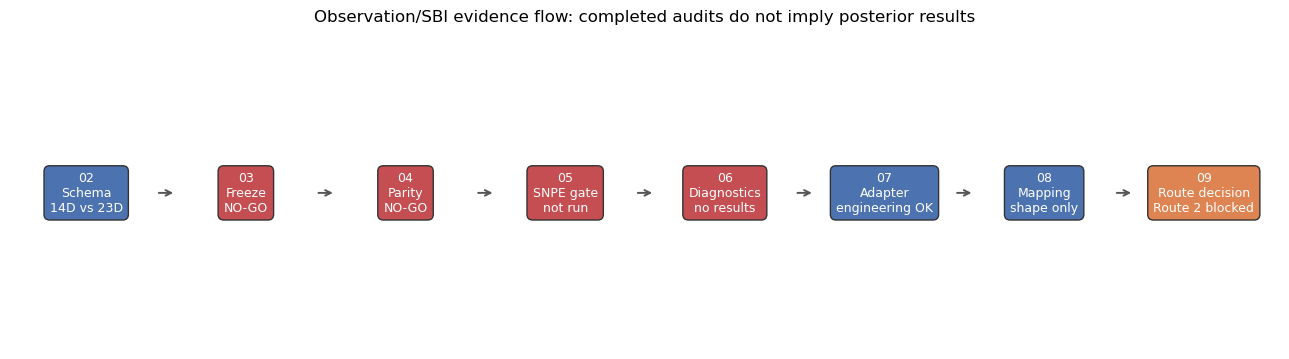

In [2]:
registry = reader_guide_registry()
notebook_dir = PROJECT_ROOT / "S4_sbi" / "notebooks"
notebook_map = {
    "02": "02_Observation_Schema_Comparison.ipynb",
    "03": "03_Observation_Schema_Freeze.ipynb",
    "04": "04_Real_Simulation_Extractor_Parity.ipynb",
    "05": "05_Pilot_SNPE_Ablation.ipynb",
    "06": "06_Ablation_Diagnostics.ipynb",
    "07": "07_Simulator_Observable_Adapter_Validation.ipynb",
    "08": "08_EEG_Observation_Mapping_Audit.ipynb",
    "09": "09_Forward_Model_Feasibility_and_Route_Decision.ipynb",
}
html_map = {
    "02": "S4_sbi/results/observation_schema_comparison/02_Observation_Schema_Comparison.html",
    "03": "S4_sbi/results/overnight_observation_ablation/html/03_Observation_Schema_Freeze.html",
    "04": "S4_sbi/results/overnight_observation_ablation/html/04_Real_Simulation_Extractor_Parity.html",
    "05": "S4_sbi/results/overnight_observation_ablation/html/05_Pilot_SNPE_Ablation.html",
    "06": "S4_sbi/results/overnight_observation_ablation/html/06_Ablation_Diagnostics.html",
    "07": "S4_sbi/results/simulator_observable_adapter_validation/html/07_Simulator_Observable_Adapter_Validation.html",
    "08": "S4_sbi/results/overnight_observation_ablation/html/08_EEG_Observation_Mapping_Audit.html",
    "09": "S4_sbi/results/overnight_observation_ablation/html/09_Forward_Model_Feasibility_and_Route_Decision.html",
}
registry["notebook_path"] = registry["notebook"].map(
    lambda key: f"S4_sbi/notebooks/{notebook_map[key]}"
)
registry["html_path"] = registry["notebook"].map(html_map)
registry["notebook_exists"] = registry["notebook_path"].map(
    lambda value: (PROJECT_ROOT / value).exists()
)
registry["html_exists"] = registry["html_path"].map(
    lambda value: (PROJECT_ROOT / value).exists()
)
assert registry["notebook_exists"].all()
display(registry)

fig, ax = plt.subplots(figsize=(13, 3.7))
ax.axis("off")
labels = [
    ("02", "Schema\n14D vs 23D", "#4c72b0"),
    ("03", "Freeze\nNO-GO", "#c44e52"),
    ("04", "Parity\nNO-GO", "#c44e52"),
    ("05", "SNPE gate\nnot run", "#c44e52"),
    ("06", "Diagnostics\nno results", "#c44e52"),
    ("07", "Adapter\nengineering OK", "#4c72b0"),
    ("08", "Mapping\nshape only", "#4c72b0"),
    ("09", "Route decision\nRoute 2 blocked", "#dd8452"),
]
xs = np.linspace(0.06, 0.94, len(labels))
for i, (key, label, color) in enumerate(labels):
    ax.text(
        xs[i],
        0.52,
        f"{key}\n{label}",
        transform=ax.transAxes,
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": color, "edgecolor": "#333333"},
    )
    if i:
        ax.annotate(
            "",
            xy=(xs[i] - 0.055, 0.52),
            xytext=(xs[i - 1] + 0.055, 0.52),
            xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#555555"},
        )
ax.set_title("Observation/SBI evidence flow: completed audits do not imply posterior results", pad=20)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"notebook_workflow.{suffix}", dpi=180 if suffix == "png" else None, bbox_inches="tight")
display(fig)
plt.close(fig)


## 3. 每本notebook最值得看的1-3个位置

- **02**：actual Baseline-14D证据、constructive prefix identity、SNPE readiness。
- **03**：freeze decision、Go/No-Go表、role figure。
- **04**：legacy bank资产审计、feature-level parity failures、hard gate。
- **05**：training gate、`BLOCKED_BY_PARITY` manifest；没有posterior。
- **06**：diagnostic availability与ablation summary；全部是insufficient evidence。
- **07**：adapter contract、feature blocker matrix、NO-GO；工程成功不等于语义成功。
- **08**：state catalog、standardized PSD/ACF、Route 2建议；仅shape screening。
- **09**：source-candidate matrix、rank-1推导、measurement contract和Route 2/3表。


In [3]:
priority_view = registry[
    [
        "notebook",
        "scientific_question",
        "priority_sections_or_figures",
        "current_conclusion",
        "cannot_claim",
        "notebook_path",
        "html_path",
    ]
]
display(priority_view)


,notebook,scientific_question,priority_sections_or_figures,current_conclusion,cannot_claim,notebook_path,html_path
0,02,What are the executable Baseline and candidate...,"Sections 3, 6, 11","Actual Baseline-14D, Augmented-23D, constructi...",Schema names are not evidence of simulator parity,S4_sbi/notebooks/02_Observation_Schema_Compari...,S4_sbi/results/observation_schema_comparison/0...
1,03,Which real-EEG candidate schemas are finite an...,Freeze decision; Go/No-Go; role figure,No schema approved because simulation extracti...,A frozen real vector alone is insufficient,S4_sbi/notebooks/03_Observation_Schema_Freeze....,S4_sbi/results/overnight_observation_ablation/...
2,04,Can existing simulation assets produce same-se...,Asset audit; feature failures; hard gate,NO-GO: legacy banks are 5D/7D rate summaries,Code-level availability is not semantic parity,S4_sbi/notebooks/04_Real_Simulation_Extractor_...,S4_sbi/results/overnight_observation_ablation/...
3,05,Did any schema pass the training gate?,Gate before training; manifest; blocker table,Training not started; zero simulations and zer...,Contains no posterior,S4_sbi/notebooks/05_Pilot_SNPE_Ablation.ipynb,S4_sbi/results/overnight_observation_ablation/...
4,06,"Which recovery, coverage or PPC results exist?",Ablation summary; availability figure; conclusion,All diagnostic entries are insufficient evidence,Contains no recovery/coverage/PPC result,S4_sbi/notebooks/06_Ablation_Diagnostics.ipynb,S4_sbi/results/overnight_observation_ablation/...
5,07,Can existing V7/V8/V8a rate signals enter shar...,Adapter contract; blocker matrix; NO-GO gate,Engineering adapter works; semantic parity fails,Cortical firing rate is not simulated EEG,S4_sbi/notebooks/07_Simulator_Observable_Adapt...,S4_sbi/results/simulator_observable_adapter_va...
6,08,Do any recorded model states already constitut...,State catalog; PSD/ACF screening; Route decision,Only standardized shape screening; no measurem...,High shape correlation is not EEG validation,S4_sbi/notebooks/08_EEG_Observation_Mapping_Au...,S4_sbi/results/overnight_observation_ablation/...
7,09,Can the single-node model support a defensible...,Source matrix; contract gate; Route 2 vs 3,Single source is rank-1; Route 2 needs externa...,Does not implement a forward model or authoriz...,S4_sbi/notebooks/09_Forward_Model_Feasibility_...,S4_sbi/results/overnight_observation_ablation/...


## 4. 已成立、未成立与hard blockers

`Established`只表示代码或审计证据成立；不等于生理机制已被识别。
`Not established`不能被空表、旧bank或较窄posterior替代。


In [4]:
evidence_status = pd.DataFrame([
    ("Actual executable baseline is 14D", "Established", "02"),
    ("Candidate augmented library is 23D", "Established", "02"),
    ("The augmented prefix is constructively the same baseline", "Established", "02"),
    ("A real-EEG schema has simulation semantic parity", "Not established", "03-04"),
    ("Engineering adapter runs V7/V8/V8a cortical rate outputs", "Established", "07"),
    ("Cortical firing rate is a validated EEG proxy", "Not established", "07-09"),
    ("Normalized model/EEG spectral shapes can be compared descriptively", "Established with caveat", "08"),
    ("A source-to-Fpz-Cz measurement model exists", "Not established", "08-09"),
    ("Pilot SNPE was trained", "False / not run", "05"),
    ("Posterior recovery, coverage, L-C2ST or PPC were obtained", "False / unavailable", "06"),
    ("Route 2 can be implemented from current node states alone", "False", "09"),
], columns=["statement", "status", "evidence_notebook"])
display(evidence_status)


,statement,status,evidence_notebook
0,Actual executable baseline is 14D,Established,02
1,Candidate augmented library is 23D,Established,02
2,The augmented prefix is constructively the sam...,Established,02
3,A real-EEG schema has simulation semantic parity,Not established,03-04
4,Engineering adapter runs V7/V8/V8a cortical ra...,Established,07
5,Cortical firing rate is a validated EEG proxy,Not established,07-09
6,Normalized model/EEG spectral shapes can be co...,Established with caveat,08
7,A source-to-Fpz-Cz measurement model exists,Not established,08-09
8,Pilot SNPE was trained,False / not run,05
9,"Posterior recovery, coverage, L-C2ST or PPC we...",False / unavailable,06


## 5. 术语速查

- **Schema**：有固定名字、顺序、单位、aggregation和validity规则的向量定义。
- **Extractor parity**：真实与模拟输入经过同语义算法后得到同名、同序、同单位的固定向量。
- **Cortical observable**：模型内部可读取量，例如population firing rate；不能自动称EEG。
- **Measurement model**：从物理source、geometry和volume conductor到sensor voltage/reference/noise的映射。
- **Shape-level validation**：标准化后比较PSD或waveform形状；不检查绝对单位和sensor语义。
- **Held-out validation**：未用于拟合、特征选择或calibration的独立证据。
- **Synthetic recovery**：已知theta生成model observable，再测试inference能否恢复theta。
- **PPC**：需要正式posterior estimator和posterior predictive simulations；当前05-06不具备。


In [5]:
glossary = pd.DataFrame([
    ("observation schema", "Ordered feature contract with units, aggregation and validity", "Does not prove simulator parity"),
    ("extractor parity", "Same-semantic real/simulation feature extraction", "Not merely same Python function"),
    ("cortical observable", "Recorded or reconstructed model-internal signal", "Not automatically scalp EEG"),
    ("measurement model", "Source-to-sensor projection, reference, units and noise", "Currently missing"),
    ("shape-level comparison", "Normalized PSD/ACF/waveform comparison", "No raw-unit claim"),
    ("held-out validation", "Evidence untouched by fitting/calibration", "Cannot reuse inference inputs"),
    ("synthetic recovery", "Recover known simulated theta", "Does not establish real-data validity"),
    ("posterior predictive check", "Simulate from a trained posterior and compare held-out observables", "No result exists in 05-06"),
], columns=["term", "working_definition", "boundary"])
display(glossary)


,term,working_definition,boundary
0,observation schema,"Ordered feature contract with units, aggregati...",Does not prove simulator parity
1,extractor parity,Same-semantic real/simulation feature extraction,Not merely same Python function
2,cortical observable,Recorded or reconstructed model-internal signal,Not automatically scalp EEG
3,measurement model,"Source-to-sensor projection, reference, units ...",Currently missing
4,shape-level comparison,Normalized PSD/ACF/waveform comparison,No raw-unit claim
5,held-out validation,Evidence untouched by fitting/calibration,Cannot reuse inference inputs
6,synthetic recovery,Recover known simulated theta,Does not establish real-data validity
7,posterior predictive check,Simulate from a trained posterior and compare ...,No result exists in 05-06


## 6. 90分钟推荐阅读路线

1. **0-15 min：02 Sections 3/6/11**，确认14D、23D和prefix identity。
2. **15-30 min：03 Go/No-Go + 04 hard gate**，理解为何现有bank不能改名复用。
3. **30-40 min：05 gate + 06 availability**，确认没有实际posterior结果。
4. **40-55 min：07 adapter contract/blocker matrix**，区分engineering与semantic parity。
5. **55-70 min：08 state catalog和PSD/ACF**，把高shape correlation放回正确边界。
6. **70-90 min：09 rank-1、contract与Route 2/3**，作研究范围决策。


In [6]:
reading_plan = pd.DataFrame([
    ("00-15", "02", "Actual 14D, 23D crosswalk, constructive prefix", "Know what the observation vectors really are"),
    ("15-30", "03-04", "Freeze and semantic-parity gates", "Know why no schema entered training"),
    ("30-40", "05-06", "Training/diagnostic availability", "Verify there is no posterior result"),
    ("40-55", "07", "Adapter and blocker matrix", "Separate engineering success from scientific parity"),
    ("55-70", "08", "State catalog and normalized shape plots", "Understand the modality caveat"),
    ("70-90", "09", "Rank-1 source, measurement contract, Route 2/3", "Make the next research-scope decision"),
], columns=["minutes", "notebook", "focus", "reading_goal"])
display(reading_plan)


,minutes,notebook,focus,reading_goal
0,00-15,02,"Actual 14D, 23D crosswalk, constructive prefix",Know what the observation vectors really are
1,15-30,03-04,Freeze and semantic-parity gates,Know why no schema entered training
2,30-40,05-06,Training/diagnostic availability,Verify there is no posterior result
3,40-55,07,Adapter and blocker matrix,Separate engineering success from scientific p...
4,55-70,08,State catalog and normalized shape plots,Understand the modality caveat
5,70-90,09,"Rank-1 source, measurement contract, Route 2/3",Make the next research-scope decision


## 7. Route decision and next human gate

近期最稳妥的是把Route 3作为**可讨论但尚未授权**的synthetic
recovery方向；Route 2保留为需要source derivation、geometry、BEM、
calibration和held-out validation的长期工作。真实SC4001只能继续作为带
modality caveat的external shape evidence。


In [7]:
routes = route_decision_matrix()
display(routes)

human_gate = pd.DataFrame([
    ("Scope", "Choose near-term Route 3 synthetic recovery or fund a Route 2 source/forward program", "Researcher"),
    ("Route 2 source", "Approve source physics and independent calibration/validation datasets", "Researcher + domain expert"),
    ("Route 3 protocol", "Freeze observable, prior, extractor, budget, seeds and diagnostics before bank generation", "Researcher"),
], columns=["decision", "question", "owner"])
display(human_gate)


,criterion,route_2_measurement_model,route_3_synthetic_observable,current_assessment
0,scientific_claim,Inference about theta conditional on a validat...,Parameter recovery for a declared model-intern...,Route 2 is stronger but unsupported now
1,required_implementation,"Source reconstruction, geometry, BEM/lead fiel...","Freeze model observable, simulator extractor, ...",Route 3 is implementable sooner
2,required_external_data,Anatomy/template plus independent measurement-...,None for synthetic recovery; real EEG only opt...,Route 2 lacks essential external evidence
3,calibration_leakage_risk,High if source/gain/noise are tuned on SC4001,Low if real EEG is excluded from tuning,Route 3 has cleaner immediate separation
4,identifiability,"theta is confounded with source weights, geome...",Identifiability of theta can be measured withi...,Route 2 currently underidentified
5,expected_time_cost,"High: source derivation, forward implementatio...",Moderate: honest simulator-bank and recovery s...,Conference horizon favors Route 3
6,conference_suitability,Only as a feasibility/limitations discussion u...,Suitable as a scoped synthetic-method result,Recommend Route 3 for near-term claims
7,can_claim,Current work can claim a documented feasibilit...,Can later claim synthetic recovery/calibration...,Neither route currently has posterior results
8,cannot_claim,No current real-EEG posterior or EEG measureme...,No inference about real Fpz-Cz physiology or p...,Keep modality boundary explicit
9,minimum_go_no_go,All contract stages pass and held-out measurem...,"Frozen observable/schema, fixed finite extract...",Both remain researcher-gated


,decision,question,owner
0,Scope,Choose near-term Route 3 synthetic recovery or...,Researcher
1,Route 2 source,Approve source physics and independent calibra...,Researcher + domain expert
2,Route 3 protocol,"Freeze observable, prior, extractor, budget, s...",Researcher


## 8. Export and validation

Reader-guide artifacts只保存索引、术语和验证状态。它们不包含原始EEG、
simulation arrays、posterior或训练结果。


In [8]:
registry.to_csv(OUTPUT_DIR / "reader_guide_registry.csv", index=False)
evidence_status.to_csv(OUTPUT_DIR / "evidence_status.csv", index=False)
glossary.to_csv(OUTPUT_DIR / "glossary.csv", index=False)
reading_plan.to_csv(OUTPUT_DIR / "reading_plan_90min.csv", index=False)
human_gate.to_csv(OUTPUT_DIR / "researcher_decisions.csv", index=False)
(OUTPUT_DIR / "environment_report.json").write_text(
    json.dumps(environment, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

reload_shapes = {}
for name in [
    "reader_guide_registry.csv",
    "evidence_status.csv",
    "glossary.csv",
    "reading_plan_90min.csv",
    "researcher_decisions.csv",
]:
    loaded = pd.read_csv(OUTPUT_DIR / name)
    assert len(loaded) > 0
    reload_shapes[name] = list(loaded.shape)
nbformat.validate(nbformat.read(NOTEBOOK_PATH, as_version=4))
validation = {
    "nbformat_validation": "PASS",
    "artifact_reload_shapes": reload_shapes,
    "notebooks_02_to_09_exist": bool(registry["notebook_exists"].all()),
    "html_available_before_external_export": int(registry["html_exists"].sum()),
    "simulation_count": 0,
    "snpe_started": False,
    "posterior_results_claimed": False,
}
(OUTPUT_DIR / "validation_report.json").write_text(
    json.dumps(validation, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print("Reader-guide artifact reload: PASS")
print("No simulation or posterior computation was run.")


Reader-guide artifact reload: PASS
No simulation or posterior computation was run.


## 9. 阅读结束后的检查问题

阅读者应能回答：

1. Baseline为什么是14D而不是被强行补成18D？
2. 为什么07的adapter success不等于EEG semantic parity？
3. 为什么08的标准化PSD相似不能证明measurement model？
4. 为什么单scalar source产生的Fpz-Cz仍然是rank-1？
5. Route 2缺哪些外部假设，Route 3又不能声称什么？

在这五个问题回答清楚前，不应生成simulation bank或启动pilot SNPE。
